# Étape 5 : Modélisation non supervisée

## Objectif
Détecter les fraudes comme des anomalies — des transactions qui dévient 
du comportement "normal" — sans utiliser les labels.

Deux approches :
- **Isolation Forest** : isole les points anormaux en les séparant 
  aléatoirement. Les anomalies sont plus faciles à isoler que les 
  points normaux.
- **Autoencoder** : un réseau de neurones qui apprend à compresser 
  puis reconstruire les transactions normales. Les fraudes, jamais 
  vues à l'entraînement, seront mal reconstruites — l'erreur de 
  reconstruction sert de score d'anomalie.

## 5.1 — Imports et chargement

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score,
                             precision_score, recall_score)

# Chargement des données prétraitées
with open('../outputs/preprocessed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']

print(f"Train : {X_train.shape[0]} transactions")
print(f"Test  : {X_test.shape[0]} transactions")

Train : 227845 transactions
Test  : 56962 transactions



## 5.2 — Isolation Forest

Principe : l'algorithme construit des arbres aléatoires qui découpent l'espace. Les points anormaux sont isolés en peu de découpages (ils sont "loin" des autres), les points normaux nécessitent beaucoup de 
découpages. Le nombre moyen de découpages = score d'anomalie.

In [3]:
# contamination = proportion attendue d'anomalies (on sait que c'est ~0.17%)
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.00173,
    random_state=42,
    n_jobs=-1
)

# On entraîne sur TOUT le train (pas de labels utilisés)
iso_forest.fit(X_train)

# Prédictions : -1 = anomalie, 1 = normal
y_pred_iso = iso_forest.predict(X_test)
# Conversion : -1 → 1 (fraude), 1 → 0 (légitime) pour matcher nos labels
y_pred_iso = np.where(y_pred_iso == -1, 1, 0)

# Scores d'anomalie (plus négatif = plus anormal)
scores_iso = iso_forest.decision_function(X_test)
# Inversion pour que plus élevé = plus anormal (pour AUC-ROC)
scores_iso_inverted = -scores_iso

# Métriques
print("=== ISOLATION FOREST ===")
print(f"Precision : {precision_score(y_test, y_pred_iso):.3f}")
print(f"Recall    : {recall_score(y_test, y_pred_iso):.3f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_iso):.3f}")
print(f"AUC-ROC   : {roc_auc_score(y_test, scores_iso_inverted):.3f}")

=== ISOLATION FOREST ===
Precision : 0.221
Recall    : 0.255
F1-Score  : 0.237
AUC-ROC   : 0.947


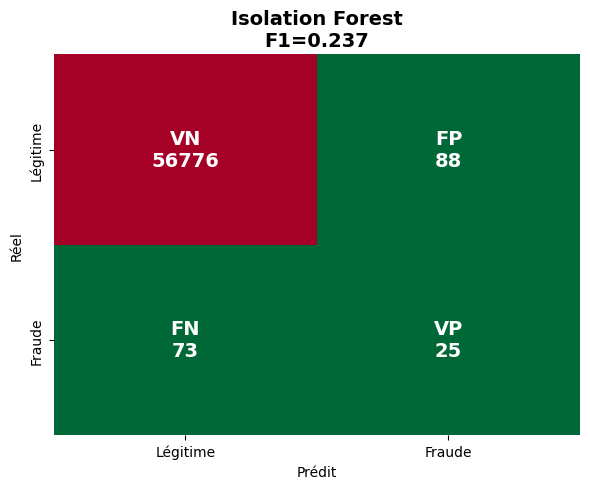

In [4]:
cm = confusion_matrix(y_test, y_pred_iso)

labels = np.array([
    [f"VN\n{cm[0][0]}", f"FP\n{cm[0][1]}"],
    [f"FN\n{cm[1][0]}", f"VP\n{cm[1][1]}"]
])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=labels, fmt='', cmap='RdYlGn_r',
            xticklabels=['Légitime', 'Fraude'],
            yticklabels=['Légitime', 'Fraude'],
            cbar=False, annot_kws={'size': 14, 'fontweight': 'bold'}, ax=ax)

ax.set_xlabel('Prédit')
ax.set_ylabel('Réel')
ax.set_title(f'Isolation Forest\nF1={f1_score(y_test, y_pred_iso):.3f}', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/confusion_matrix_isolation_forest.png', dpi=150, bbox_inches='tight')
plt.show()

### Analyse — Isolation Forest

Le F1-Score de 0.237 est nettement inférieur aux modèles supervisés (XGBoost : 0.860). 
Ce résultat est attendu : Isolation Forest n'utilise aucun label et ne sait pas 
ce qu'est une fraude. Il détecte uniquement ce qui est "anormal".

Cette approche a une limite fondamentale : une transaction peut être anormale sans 
être frauduleuse (un achat exceptionnellement élevé) et une fraude peut ressembler 
à une transaction normale (un petit achat test avec une carte volée).

Une optimisation des hyperparamètres pourrait améliorer légèrement les résultats, 
mais le plafond de performance est structurel — un modèle non supervisé ne 
rivalisera pas avec un modèle qui apprend directement à partir d'exemples de fraudes.

**Cependant, Isolation Forest reste pertinent en production** : il peut détecter de 
nouveaux types de fraude que le modèle supervisé n'a jamais vus dans ses données 
d'entraînement. Les deux approches sont complémentaires, pas concurrentes.

## 5.3 — Autoencoder avec Keras

In [7]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

# On entraîne UNIQUEMENT sur les transactions légitimes
X_train_legit = X_train[y_train == 0]
print(f"Entraînement sur {X_train_legit.shape[0]} transactions légitimes")

# Architecture de l'autoencoder
input_dim = X_train.shape[1]

# Encodeur : compresse de 34 features → 16 → 8
# Décodeur : reconstruit de 8 → 16 → 34
input_layer = Input(shape=(input_dim,))
encoded = Dense(16, activation='relu')(input_layer)
encoded = Dense(8, activation='relu')(encoded)
decoded = Dense(16, activation='relu')(encoded)
decoded = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

print(autoencoder.summary())

Entraînement sur 227451 transactions légitimes


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 34)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 34)             │           578 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,418 (5.54 KB)

 Trainable params: 1,418 (5.54 KB)

 Non-trainable params: 0 (0.00 B)

None


In [8]:
# Entraînement
history = autoencoder.fit(
    X_train_legit, X_train_legit,
    epochs=50,
    batch_size=256,
    validation_split=0.1,
    shuffle=True,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=1
)

Epoch 1/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 695us/step - loss: 1.5118 - val_loss: 0.6570
Epoch 2/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 612us/step - loss: 0.5858 - val_loss: 0.5160
Epoch 3/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 609us/step - loss: 0.4600 - val_loss: 0.3948
Epoch 4/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 609us/step - loss: 0.3840 - val_loss: 0.3618
Epoch 5/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 626us/step - loss: 0.3629 - val_loss: 0.3487
Epoch 6/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 602us/step - loss: 0.3501 - val_loss: 0.3496
Epoch 7/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 611us/step - loss: 0.3420 - val_loss: 0.3323
Epoch 8/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 605us/step - loss: 0.3353 - val_loss: 0.3259
Epoch 9/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 616us/step - loss: 0.3288 - val_loss: 0.3190
Epoch 10/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 632us/step - loss: 0.3236 - val_loss: 0.3152
Epoch 11/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 608us/step - loss: 0.3196 - val_loss: 0.3130
Epoch 12/50
800/800 ━━━━━━━━━━

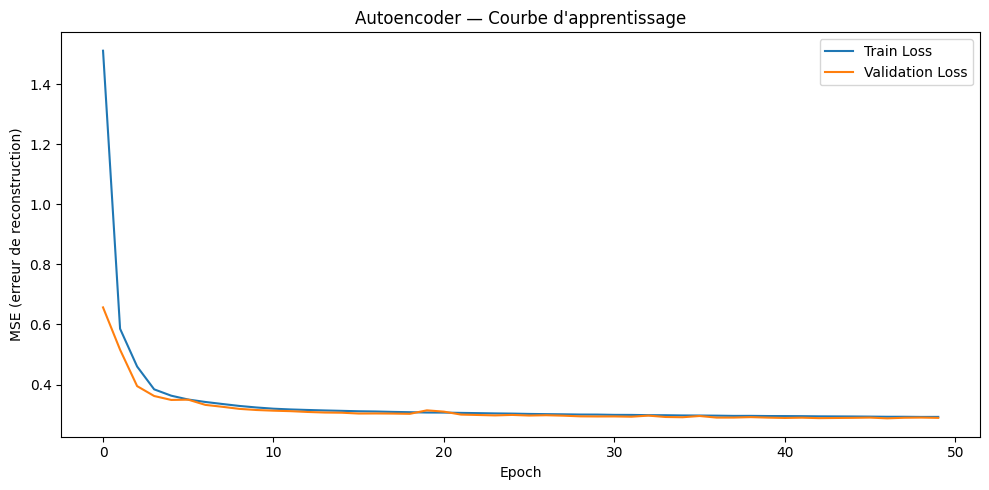

In [9]:
# Visualisation de la loss
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history.history['loss'], label='Train Loss')
ax.plot(history.history['val_loss'], label='Validation Loss')
ax.set_title("Autoencoder — Courbe d'apprentissage")
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE (erreur de reconstruction)')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/autoencoder_loss.png', dpi=150, bbox_inches='tight')
plt.show()

### Courbe d'apprentissage de l'Autoencoder

La loss chute rapidement dans les 10 premières epochs puis se stabilise 
autour de 0.3. Les courbes train et validation convergent et restent 
proches, ce qui indique que le modèle ne souffre pas d'overfitting : 
il apprend des patterns généralisables et ne mémorise pas les données 
d'entraînement.

## 5.4 — Évaluation de l'Autoencoder

In [10]:
# Calcul de l'erreur de reconstruction pour chaque transaction du test
X_test_pred = autoencoder.predict(X_test)
mse_test = np.mean(np.power(X_test - X_test_pred, 2), axis=1)

# On doit choisir un seuil : au-dessus = fraude
# On utilise le 99.83e percentile (même ratio que le dataset)
threshold = np.percentile(mse_test, 99.83)
y_pred_ae = (mse_test > threshold).astype(int)

print(f"Seuil de reconstruction : {threshold:.4f}")
print(f"\n=== AUTOENCODER ===")
print(f"Precision : {precision_score(y_test, y_pred_ae):.3f}")
print(f"Recall    : {recall_score(y_test, y_pred_ae):.3f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_ae):.3f}")
print(f"AUC-ROC   : {roc_auc_score(y_test, mse_test):.3f}")


1781/1781 ━━━━━━━━━━━━━━━━━━━━ 1s 317us/step
Seuil de reconstruction : 10.3331

=== AUTOENCODER ===
Precision : 0.454
Recall    : 0.449
F1-Score  : 0.451
AUC-ROC   : 0.965


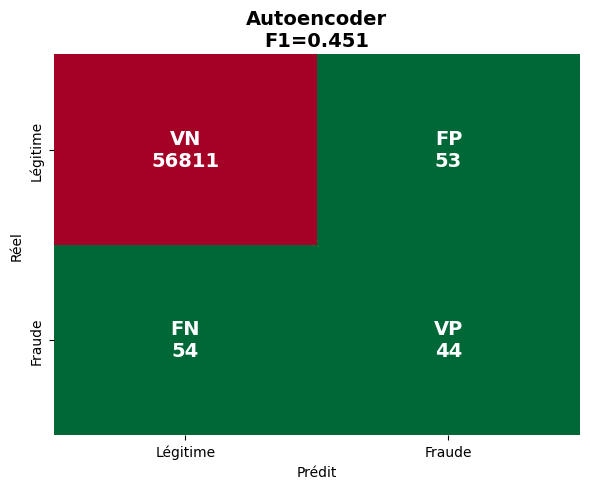

In [11]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_ae)
labels = np.array([
    [f"VN\n{cm[0][0]}", f"FP\n{cm[0][1]}"],
    [f"FN\n{cm[1][0]}", f"VP\n{cm[1][1]}"]
])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=labels, fmt='', cmap='RdYlGn_r',
            xticklabels=['Légitime', 'Fraude'],
            yticklabels=['Légitime', 'Fraude'],
            cbar=False, annot_kws={'size': 14, 'fontweight': 'bold'}, ax=ax)
ax.set_xlabel('Prédit')
ax.set_ylabel('Réel')
ax.set_title(f'Autoencoder\nF1={f1_score(y_test, y_pred_ae):.3f}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/confusion_matrix_autoencoder.png', dpi=150, bbox_inches='tight')
plt.show()

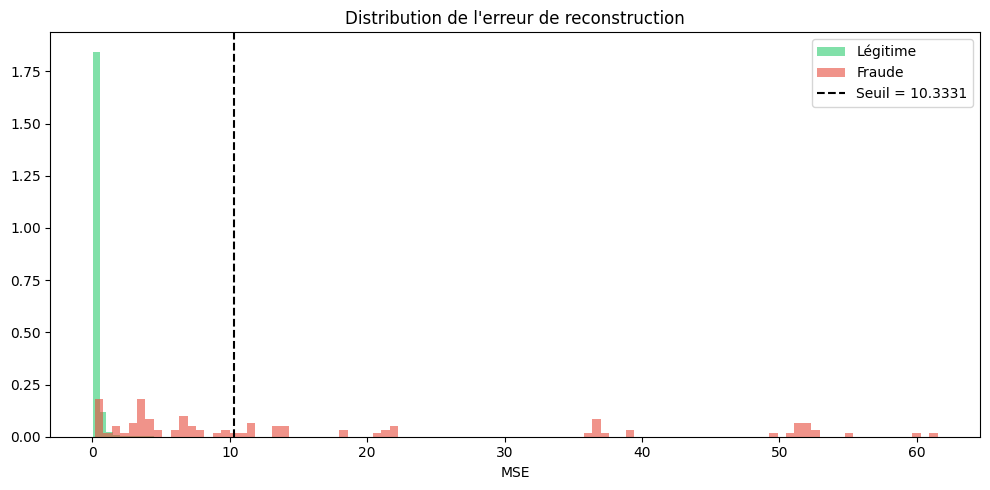

In [12]:
# Distribution des erreurs de reconstruction
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(mse_test[y_test == 0], bins=100, alpha=0.6, label='Légitime', color='#2ecc71', density=True)
ax.hist(mse_test[y_test == 1], bins=100, alpha=0.6, label='Fraude', color='#e74c3c', density=True)
ax.axvline(threshold, color='black', linestyle='--', label=f'Seuil = {threshold:.4f}')
ax.set_title("Distribution de l'erreur de reconstruction")
ax.set_xlabel('MSE')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/autoencoder_reconstruction_error.png', dpi=150, bbox_inches='tight')
plt.show()

### Analyse — Autoencoder

F1-Score de 0.451 — nettement meilleur qu'Isolation Forest (0.237) mais 
inférieur aux modèles supervisés (XGBoost : 0.860).

L'AUC-ROC de 0.965 montre que l'autoencoder a une forte capacité à 
distinguer les fraudes des légitimes. Le F1 plus faible s'explique par 
le choix du seuil de reconstruction : de nombreuses fraudes ont une 
erreur inférieure au seuil et ne sont pas détectées (54 FN).

Le graphique de distribution confirme cette analyse : les légitimes 
(vert) sont concentrées autour d'une erreur faible, les fraudes (rouge) 
sont étalées vers des erreurs plus élevées, mais les deux distributions 
se chevauchent entre 0 et 10 — c'est dans cette zone que le modèle 
hésite.

**Bilan du non supervisé** : l'Autoencoder surpasse Isolation Forest 
mais ne rivalise pas avec les modèles supervisés. Ces approches restent 
complémentaires en production pour détecter des fraudes inédites.

## 5.5 — Optimisation du seuil de l'Autoencoder

In [13]:
# On teste plusieurs seuils et on regarde le F1 pour chacun
thresholds = np.linspace(np.percentile(mse_test, 95), np.percentile(mse_test, 99.99), 200)

f1_scores = []
precisions = []
recalls = []

for t in thresholds:
    y_pred_t = (mse_test > t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t))
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t))

# Meilleur seuil
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

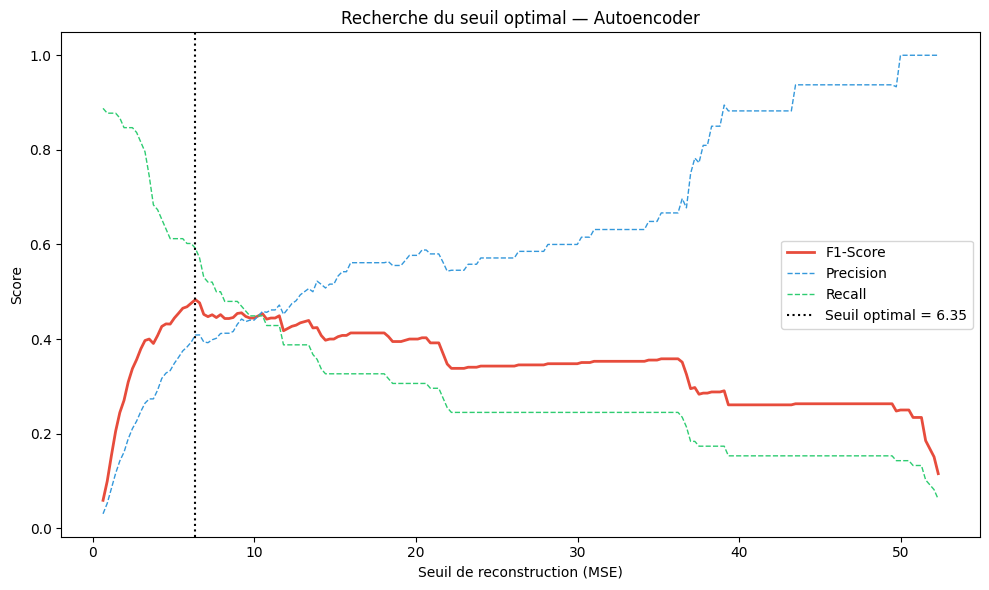

In [14]:
# Visualisation
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds, f1_scores, label='F1-Score', color='#e74c3c', linewidth=2)
ax.plot(thresholds, precisions, label='Precision', color='#3498db', linewidth=1, linestyle='--')
ax.plot(thresholds, recalls, label='Recall', color='#2ecc71', linewidth=1, linestyle='--')
ax.axvline(best_threshold, color='black', linestyle=':', label=f'Seuil optimal = {best_threshold:.2f}')
ax.set_xlabel('Seuil de reconstruction (MSE)')
ax.set_ylabel('Score')
ax.set_title('Recherche du seuil optimal — Autoencoder')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/autoencoder_threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Résultats avec le seuil optimal
y_pred_optimal = (mse_test > best_threshold).astype(int)
print(f"=== SEUIL OPTIMAL : {best_threshold:.2f} (vs {threshold:.2f} avant) ===")
print(f"Precision : {precision_score(y_test, y_pred_optimal):.3f}")
print(f"Recall    : {recall_score(y_test, y_pred_optimal):.3f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_optimal):.3f}")

# Matrice de confusion avec seuil optimal
cm = confusion_matrix(y_test, y_pred_optimal)
print(f"\nVN={cm[0][0]}, FP={cm[0][1]}")
print(f"FN={cm[1][0]}, VP={cm[1][1]}")

=== SEUIL OPTIMAL : 6.35 (vs 10.33 avant) ===
Precision : 0.408
Recall    : 0.592
F1-Score  : 0.483

VN=56780, FP=84
FN=40, VP=58


### Optimisation du seuil

En abaissant le seuil de 10.33 à 6.35, le F1 passe de 0.451 à 0.483 
et le Recall s'améliore de 0.449 à 0.592 (58 fraudes détectées contre 
44 avant). Le graphique montre cependant que le F1 ne dépasse jamais 
~0.48 quel que soit le seuil — le plafond de performance est structurel 
et confirme la limite du non supervisé face au supervisé.